# Decoding Airbnb Pricing: A Spatial Machine Learning Approach

## 1. Motivation: The Chaos of Airbnb Pricing
Airbnb pricing often feels chaotic. Two listings with similar features can have completely different prices—even in the same city. This raises a key question: **what actually drives Airbnb prices, and can I detect patterns or anomalies in how hosts price their listings?**

In this notebook, I move beyond basic statistics and apply machine learning techniques (clustering and anomaly detection) to uncover hidden structures in the data. Crucially, I leverage geographic information—like exact coordinates, distance to the city center, and attraction proximity—to study how location impacts pricing across different European cities.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

## 2. Data Processing and Feature Engineering
I utilized the dataset "Determinants of Airbnb prices in European cities" (Gyódi & Nawaro, 2021) from Zenodo. The raw data consists of multiple CSV files separated by city and day type (weekdays vs. weekends). 

To conduct a comprehensive analysis, I built a script to merge these files into a single, massive dataset while extracting the city and day type from the filenames to use as new categorical features.

In [20]:
# Load and merge the data
print("Merging city datasets...")
file_paths = glob.glob('data/*.csv')
dataframes = []

for file in file_paths:
    temp_df = pd.read_csv(file)
    
    # Extract filename without the extension (e.g., 'amsterdam_weekdays')
    filename = os.path.basename(file).replace('.csv', '')
    parts = filename.split('_')
    print(f"Processing file: {file} -> city: {parts[0].capitalize()}, is_weekend: {'weekends' in parts}")
    # Create new features based on the file name
    if len(parts) >= 2:
        temp_df['city'] = parts[0].capitalize()
        temp_df['is_weekend'] = 'weekends' == parts[1]
        
    dataframes.append(temp_df)
bool_cols = ['room_shared', 'room_private', 'host_is_superhost', 'is_weekend']

# Apply the conversion to all listed columns

# Concatenate into one master DataFrame
df = pd.concat(dataframes, ignore_index=True)
# df[bool_cols] = df[bool_cols].astype(int)
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')  # Drop the index column if it exists
print(f"Merge complete!")
print(df.columns)
print(df.head())

Merging city datasets...
Processing file: data/amsterdam_weekdays.csv -> city: Amsterdam, is_weekend: False
Processing file: data/amsterdam_weekends.csv -> city: Amsterdam, is_weekend: True
Processing file: data/athens_weekdays.csv -> city: Athens, is_weekend: False
Processing file: data/athens_weekends.csv -> city: Athens, is_weekend: True
Processing file: data/barcelona_weekdays.csv -> city: Barcelona, is_weekend: False
Processing file: data/barcelona_weekends.csv -> city: Barcelona, is_weekend: True
Processing file: data/berlin_weekdays.csv -> city: Berlin, is_weekend: False
Processing file: data/berlin_weekends.csv -> city: Berlin, is_weekend: True
Processing file: data/budapest_weekdays.csv -> city: Budapest, is_weekend: False
Processing file: data/budapest_weekends.csv -> city: Budapest, is_weekend: True
Processing file: data/lisbon_weekdays.csv -> city: Lisbon, is_weekend: False
Processing file: data/lisbon_weekends.csv -> city: Lisbon, is_weekend: True
Processing file: data/lon

In [21]:
# 1. Automatically find all columns that are integers or booleans
cols_to_convert = df.select_dtypes(include=['int64', 'int32', 'bool']).columns

# 2. Convert all of those columns to float at once
df[cols_to_convert] = df[cols_to_convert].astype(float)

# 3. Verify the changes
print(df.dtypes)

realSum                       float64
room_type                      object
room_shared                   float64
room_private                  float64
person_capacity               float64
host_is_superhost             float64
multi                         float64
biz                           float64
cleanliness_rating            float64
guest_satisfaction_overall    float64
bedrooms                      float64
dist                          float64
metro_dist                    float64
attr_index                    float64
attr_index_norm               float64
rest_index                    float64
rest_index_norm               float64
lng                           float64
lat                           float64
city                           object
is_weekend                    float64
dtype: object


## 3. Uncovering Structure (City-by-City Clustering)
To map the natural market segments, I evaluated each city individually. I applied **K-Means** (optimized using Silhouette Scores) to group listings into price and location tiers. To complement this, I applied **DBSCAN** to map the physical density of these neighborhoods and find dense tourist hubs.

For both models, I calculated the **average price of each cluster** and included it directly in the visualization legends, allowing us to instantly identify the "Budget" vs. "Premium" neighborhoods and see how density impacts price.


Analyzing Market Segments & Density for: Amsterdam
Optimal K-Means clusters: 2 (Silhouette Score: 0.313)


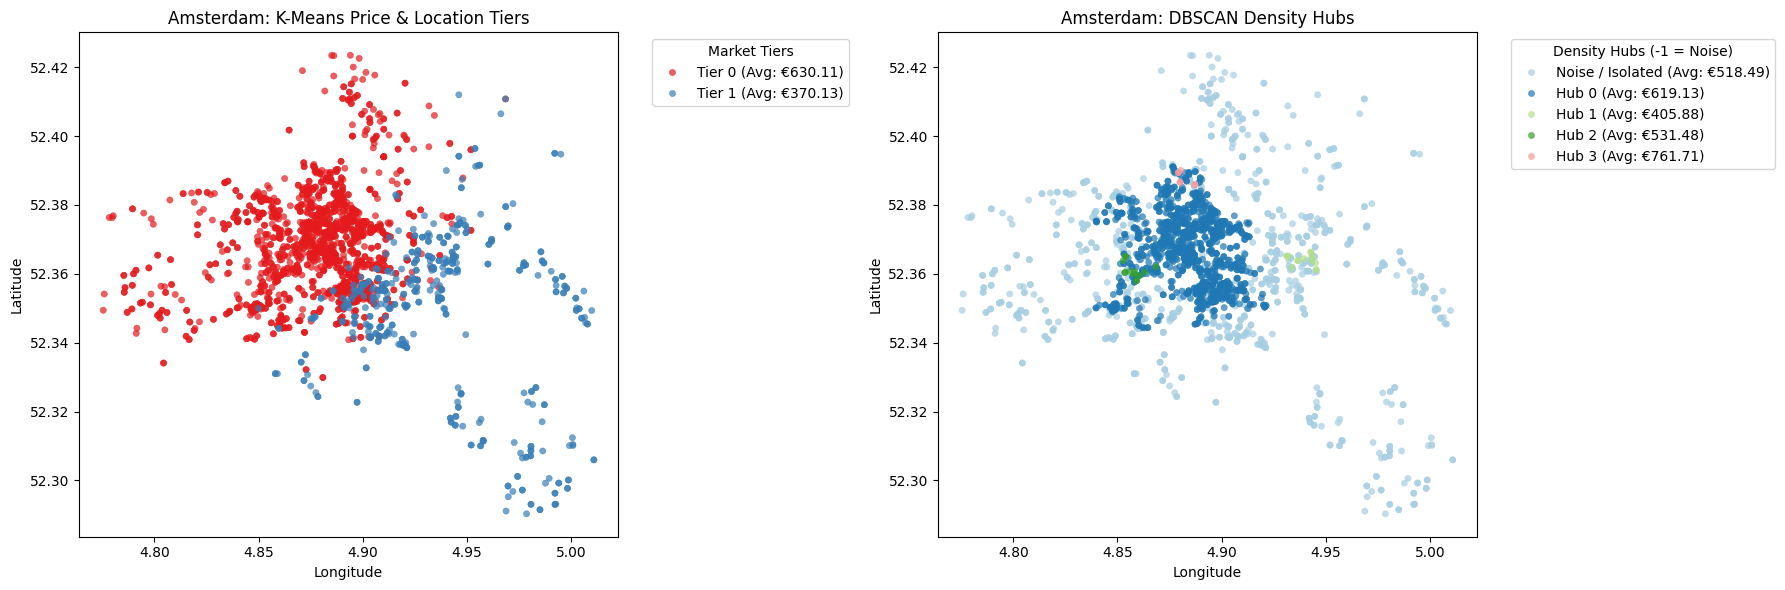


Analyzing Market Segments & Density for: Athens
Optimal K-Means clusters: 3 (Silhouette Score: 0.324)


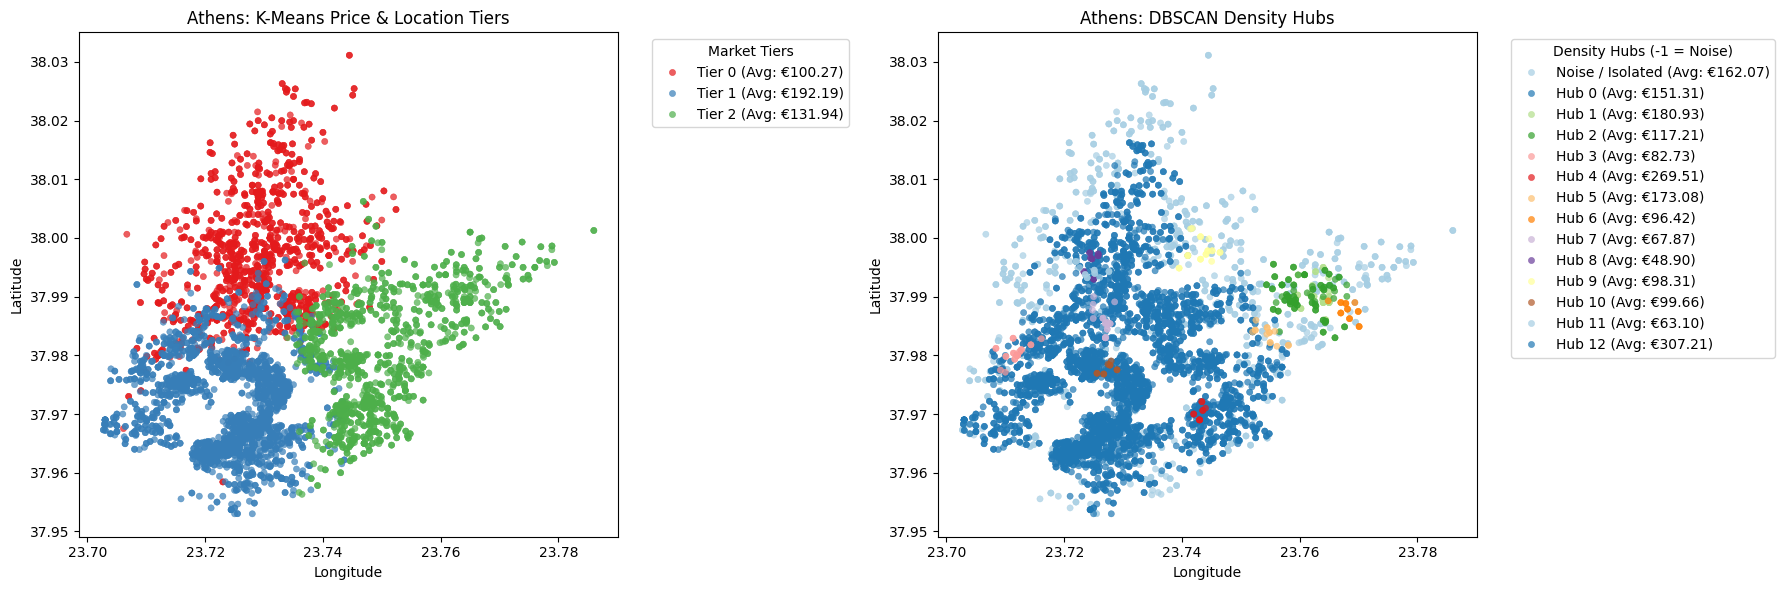


Analyzing Market Segments & Density for: Barcelona
Optimal K-Means clusters: 2 (Silhouette Score: 0.337)


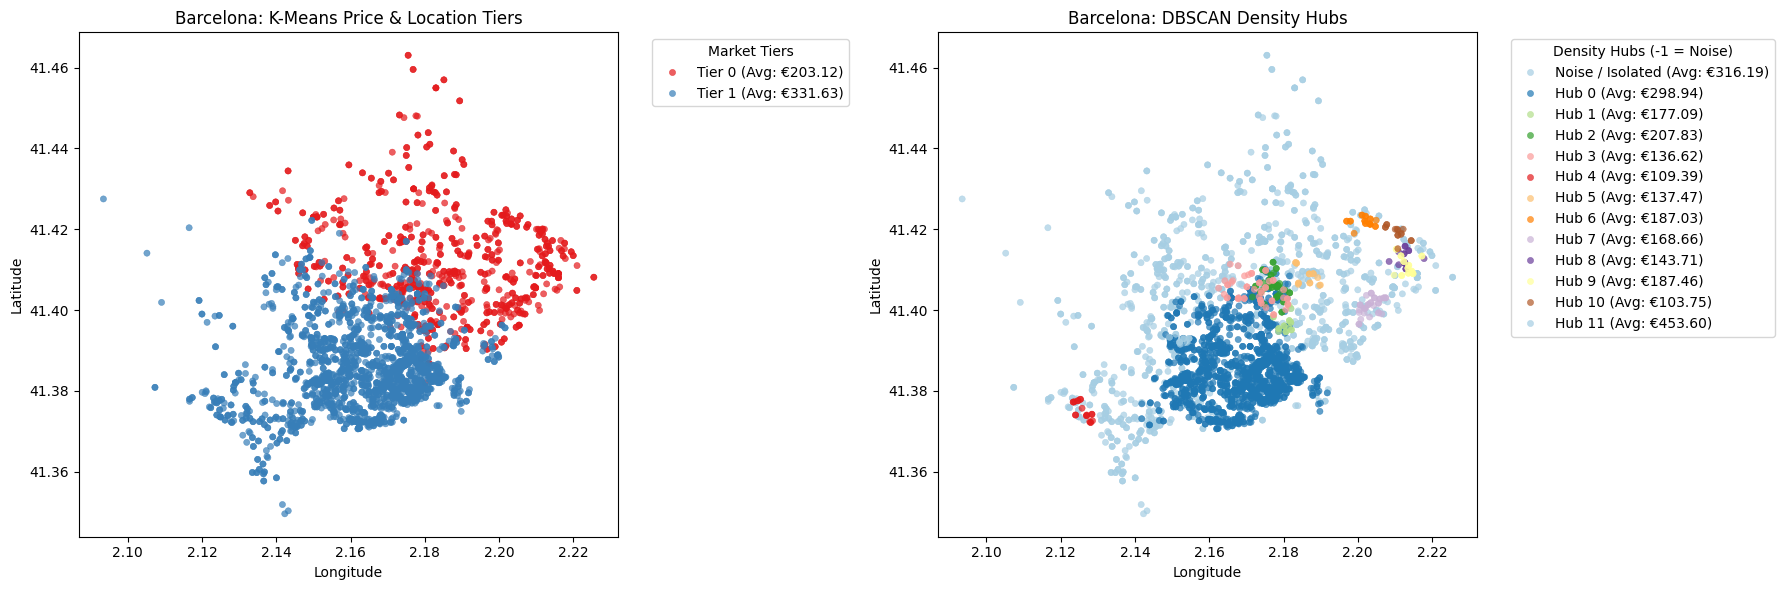


Analyzing Market Segments & Density for: Berlin
Optimal K-Means clusters: 4 (Silhouette Score: 0.281)


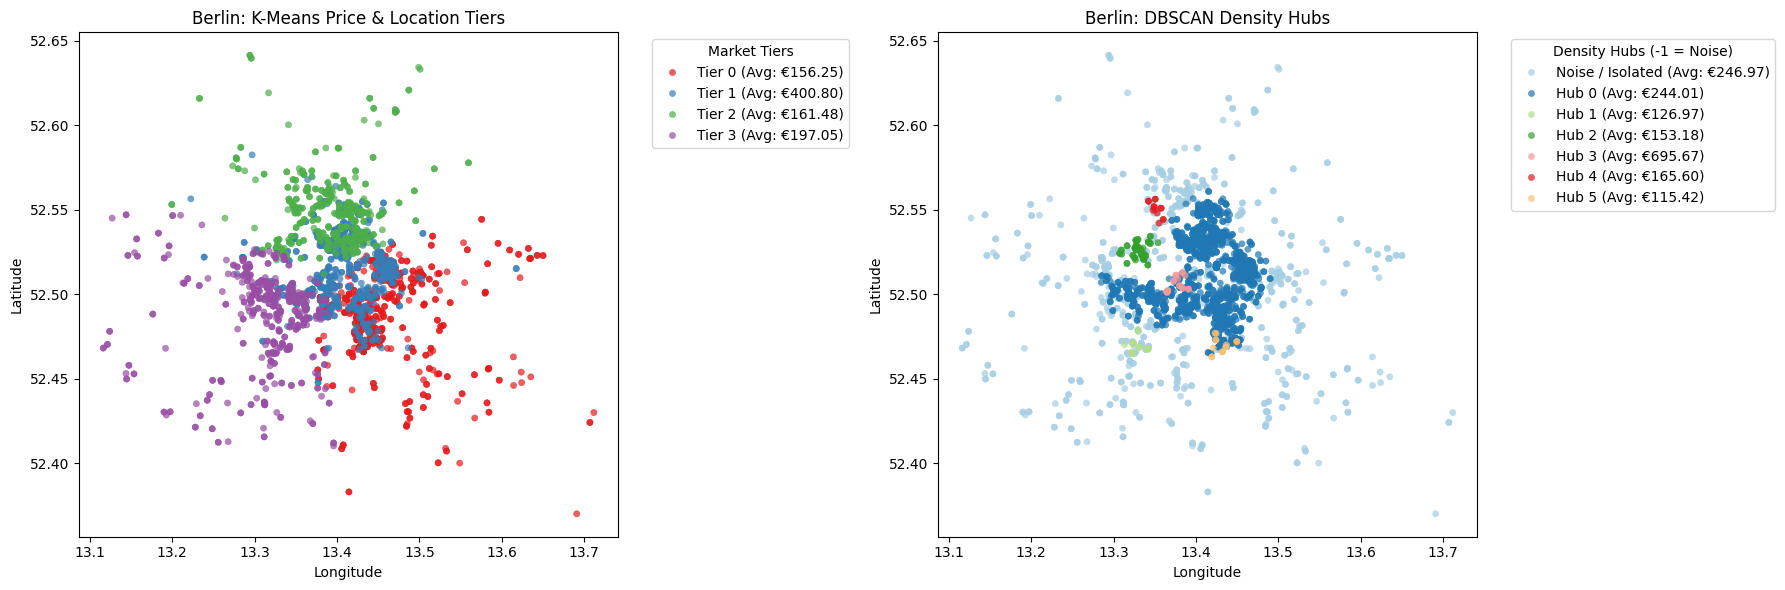


Analyzing Market Segments & Density for: Budapest
Optimal K-Means clusters: 2 (Silhouette Score: 0.682)


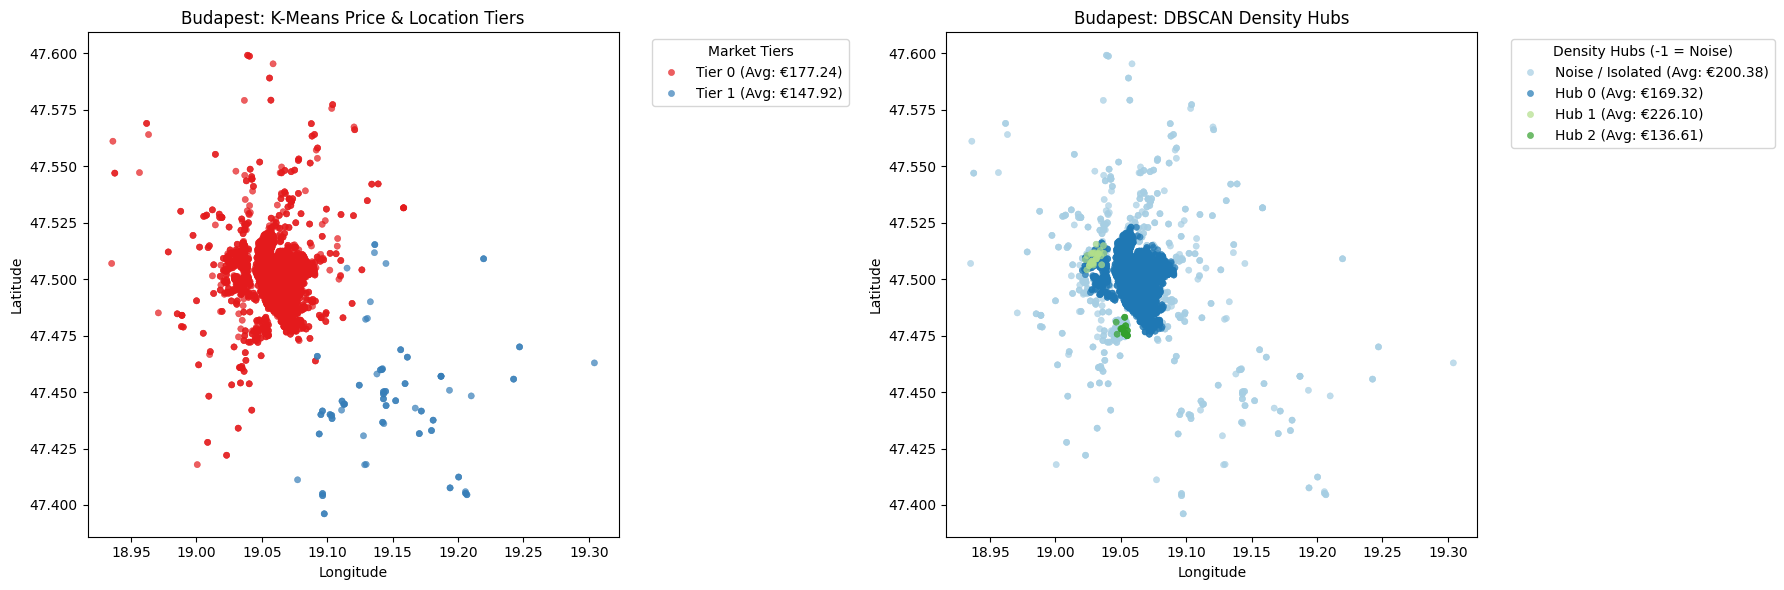


Analyzing Market Segments & Density for: Lisbon
Optimal K-Means clusters: 3 (Silhouette Score: 0.366)


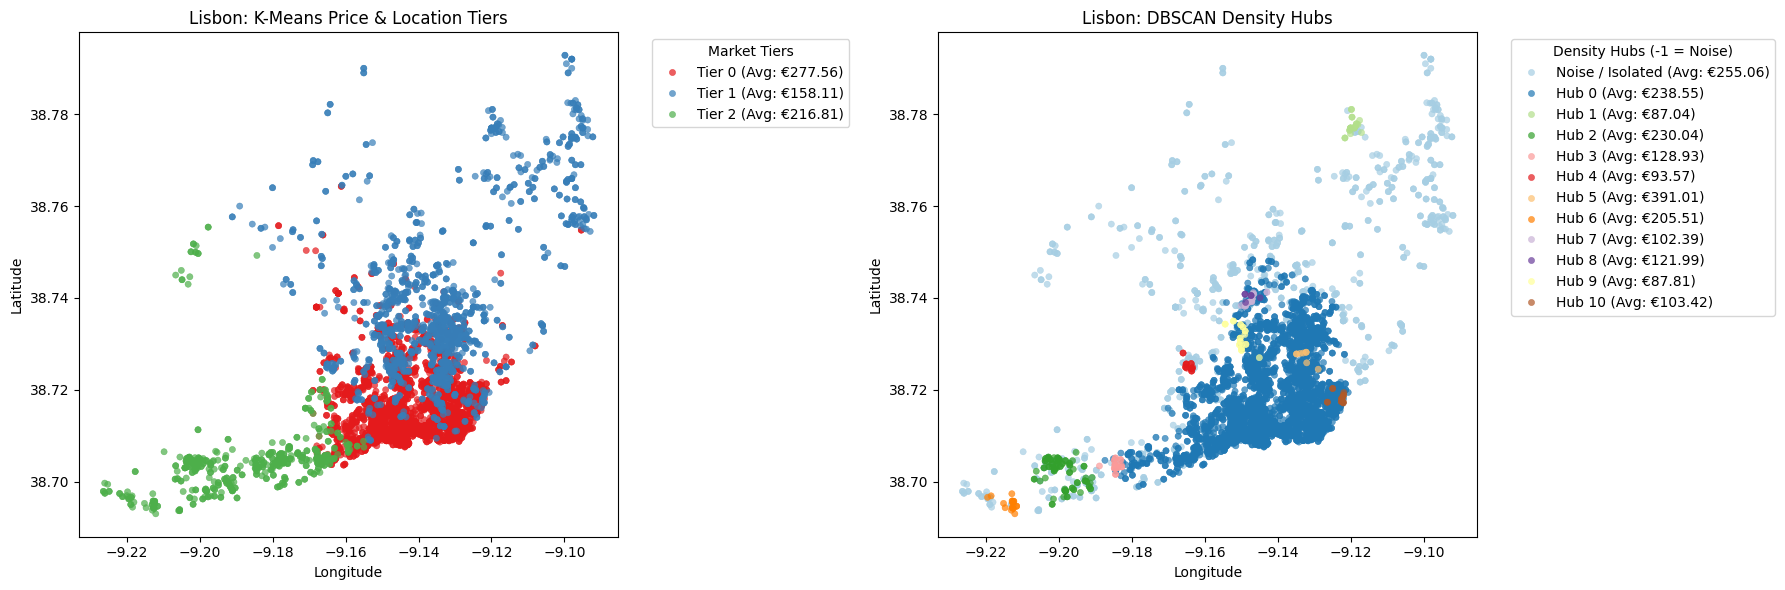


Analyzing Market Segments & Density for: London
Optimal K-Means clusters: 3 (Silhouette Score: 0.295)


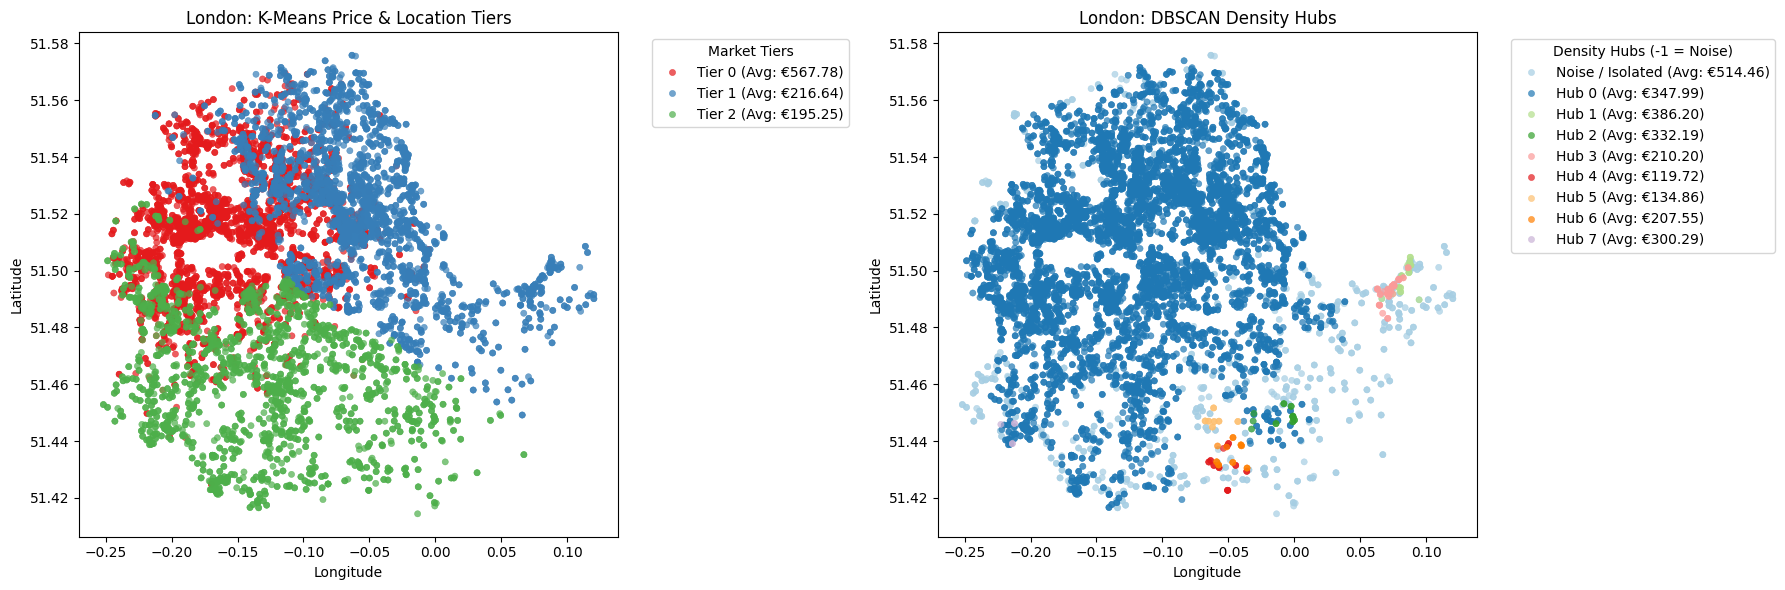


Analyzing Market Segments & Density for: Paris
Optimal K-Means clusters: 5 (Silhouette Score: 0.288)


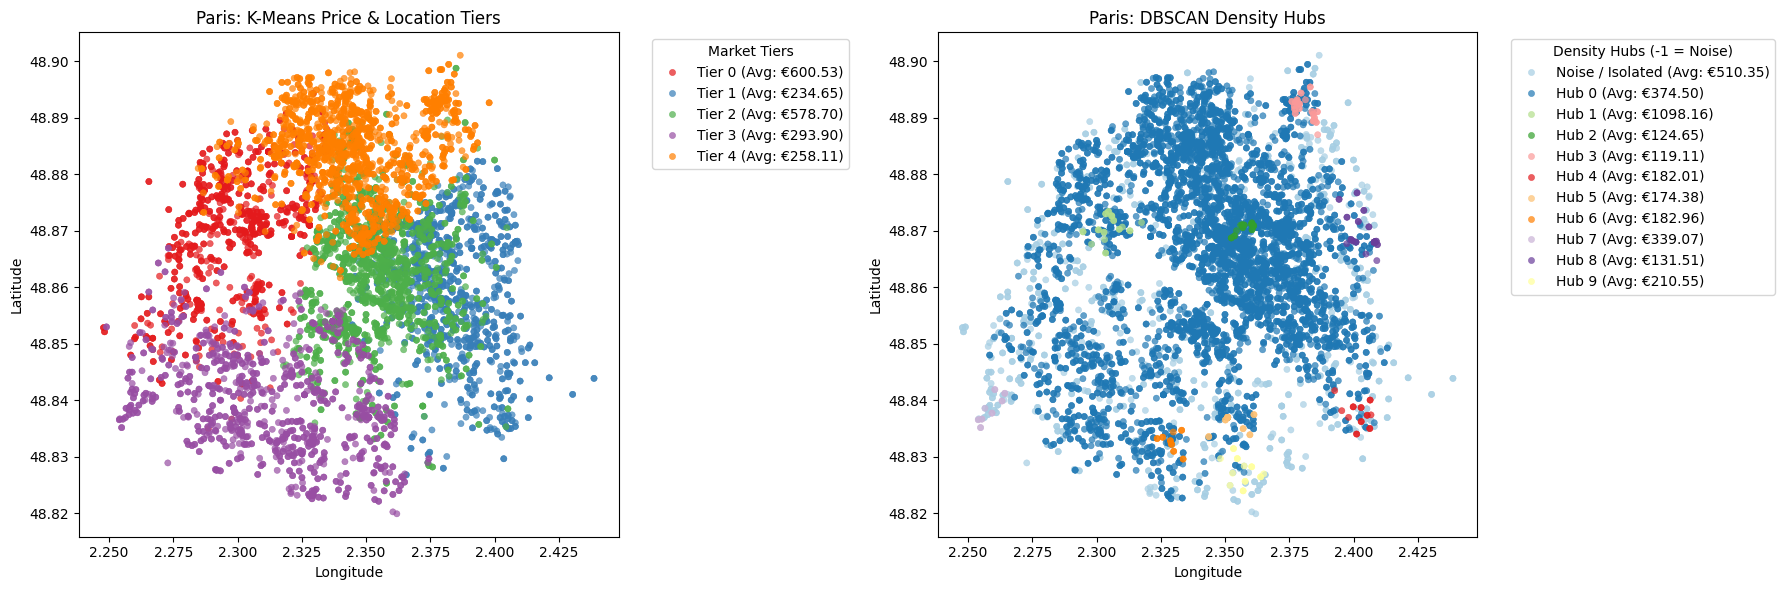


Analyzing Market Segments & Density for: Rome
Optimal K-Means clusters: 5 (Silhouette Score: 0.315)


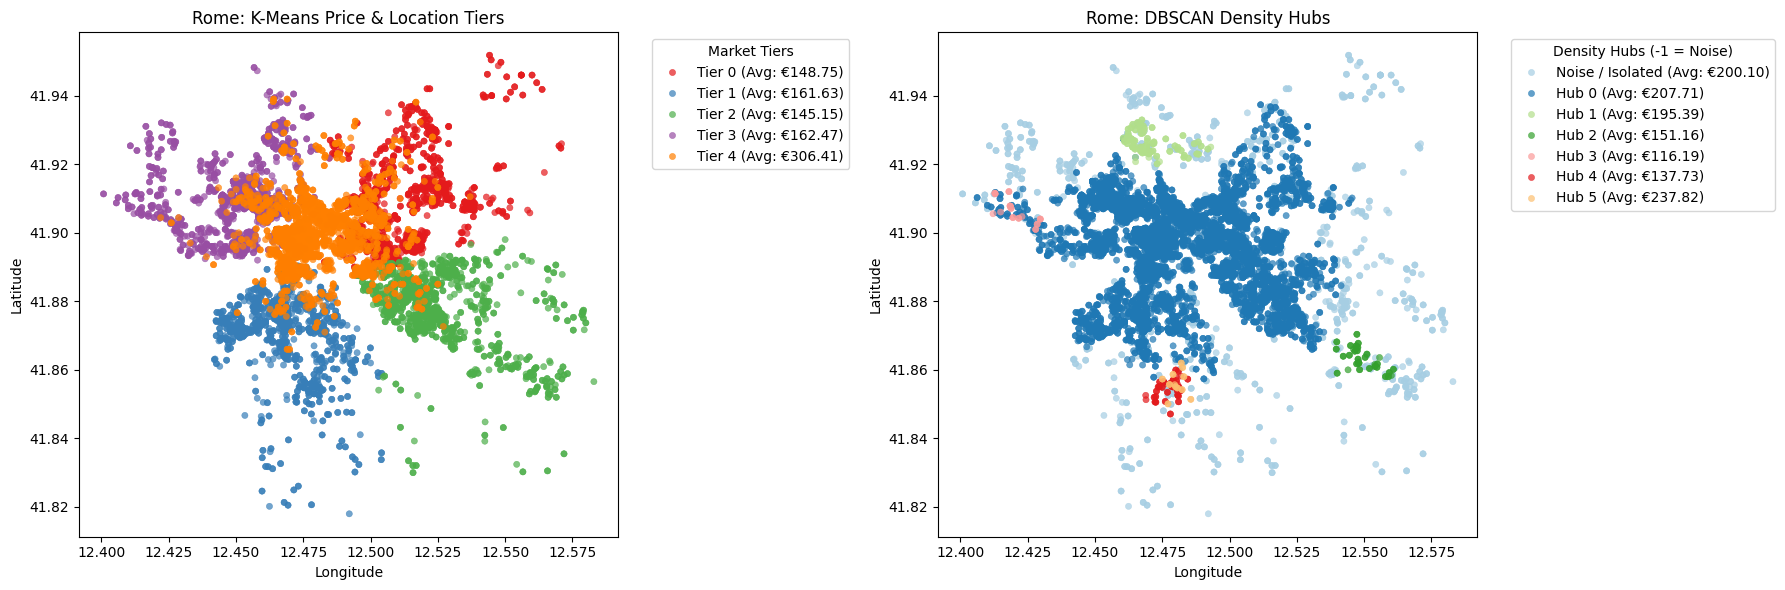


Analyzing Market Segments & Density for: Vienna
Optimal K-Means clusters: 2 (Silhouette Score: 0.254)


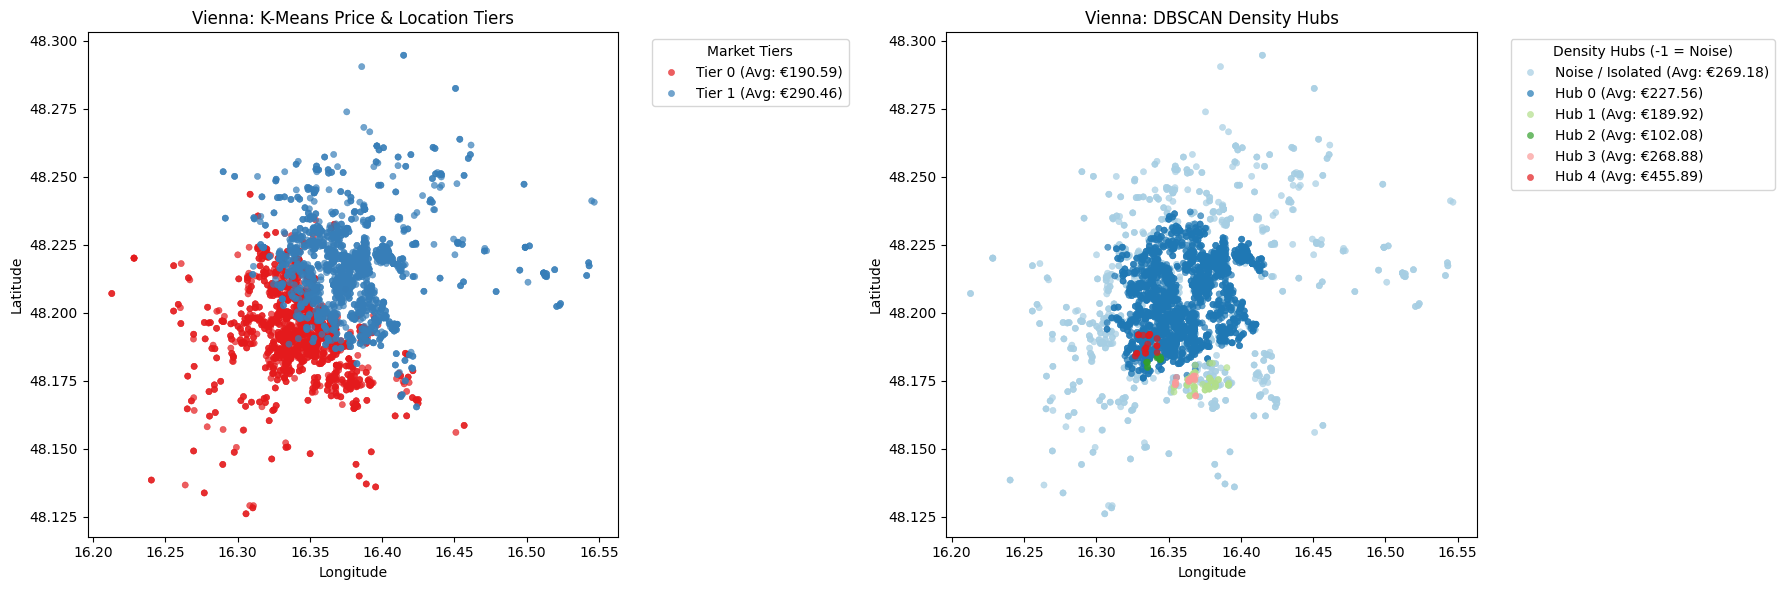

In [25]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
cities = df['city'].dropna().unique()

for city in cities:
    print(f"\n{'='*60}")
    print(f"Analyzing Market Segments & Density for: {city}")
    print(f"{'='*60}")
    
    # 1. Prepare data for the specific city
    city_df = df[df['city'] == city].copy()
    cluster_data = city_df[['lat', 'lng', 'realSum']].dropna()
    
    if len(cluster_data) < 50:
        print(f"Not enough data for {city}. Skipping...")
        continue

    # Scale data to handle extreme price skewness and align spatial features
    scaler = StandardScaler()
    pt = PowerTransformer()
    cluster_data['realSum_scaled'] = pt.fit_transform(cluster_data[['realSum']])
    cluster_data[['lat_scaled', 'lng_scaled']] = scaler.fit_transform(cluster_data[['lat', 'lng']])
    X_cluster = cluster_data[['lat_scaled', 'lng_scaled', 'realSum_scaled']]

    # 2. Optimize and Fit K-Means
    best_k, best_score = 2, -1
    for k in range(2, 6):
        kmeans_temp = KMeans(n_clusters=k, init='k-means++', n_init=20, max_iter=300, random_state=42)
        score = silhouette_score(X_cluster, kmeans_temp.fit_predict(X_cluster))
        if score > best_score:
            best_score, best_k = score, k

    kmeans_final = KMeans(n_clusters=best_k, init='k-means++', n_init=50, max_iter=500, random_state=42)
    cluster_data['KMeans_Cluster'] = kmeans_final.fit_predict(X_cluster)
    
    # 3. Fit DBSCAN
    cluster_data['DBSCAN_Cluster'] = DBSCAN(eps=0.3, min_samples=15).fit_predict(X_cluster)

    # 4. Calculate Average Prices for Legends
    # Get KMeans average prices
    kmeans_avg = cluster_data.groupby('KMeans_Cluster')['realSum'].mean()
    # Create a dynamic label column for Seaborn
    cluster_data['KMeans_Label'] = cluster_data['KMeans_Cluster'].apply(
        lambda c: f"Tier {c} (Avg: €{kmeans_avg[c]:.2f})"
    )
    
    # Get DBSCAN average prices
    dbscan_avg = cluster_data.groupby('DBSCAN_Cluster')['realSum'].mean()
    # Create a dynamic label column for Seaborn
    cluster_data['DBSCAN_Label'] = cluster_data['DBSCAN_Cluster'].apply(
        lambda c: f"Noise / Isolated (Avg: €{dbscan_avg[c]:.2f})" if c == -1 else f"Hub {c} (Avg: €{dbscan_avg[c]:.2f})"
    )

    print(f"Optimal K-Means clusters: {best_k} (Silhouette Score: {best_score:.3f})")

    # 5. Side-by-Side Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Plot A: K-Means
    sns.scatterplot(
        data=cluster_data.sort_values('KMeans_Cluster'), 
        x='lng', y='lat', 
        hue='KMeans_Label', 
        palette='Set1', s=20, alpha=0.7, edgecolor=None, ax=axes[0]
    )
    axes[0].set_title(f"{city}: K-Means Price & Location Tiers")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    # Move legend outside the plot
    axes[0].legend(title="Market Tiers", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Plot B: DBSCAN
    sns.scatterplot(
        data=cluster_data.sort_values('DBSCAN_Cluster'), 
        x='lng', y='lat', 
        hue='DBSCAN_Label', 
        palette='Paired', s=20, alpha=0.7, edgecolor=None, ax=axes[1]
    )
    axes[1].set_title(f"{city}: DBSCAN Density Hubs")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    # Move legend outside the plot
    axes[1].legend(title="Density Hubs (-1 = Noise)", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Adjust layout so legends don't get cut off
    plt.tight_layout()
    plt.show()

## 4. Finding the Outliers (Anomaly Detection)
While the majority of the Airbnb market is rational and governed by spatial rules (e.g., closer to the center or major attractions = more expensive), not all listings follow these standard market trends. Some are significantly overpriced or underpriced compared to similar properties in their exact vicinity. 

To uncover these, I utilized an **Isolation Forest** ensemble algorithm, isolating the top 5% most unusual listings across the European market. By plotting these anomalies against their distance to the city center and proximity to tourist hotspots (Attraction Index), we can clearly detect aggressive pricing strategies—such as hosts charging downtown luxury prices for remote, disconnected properties.

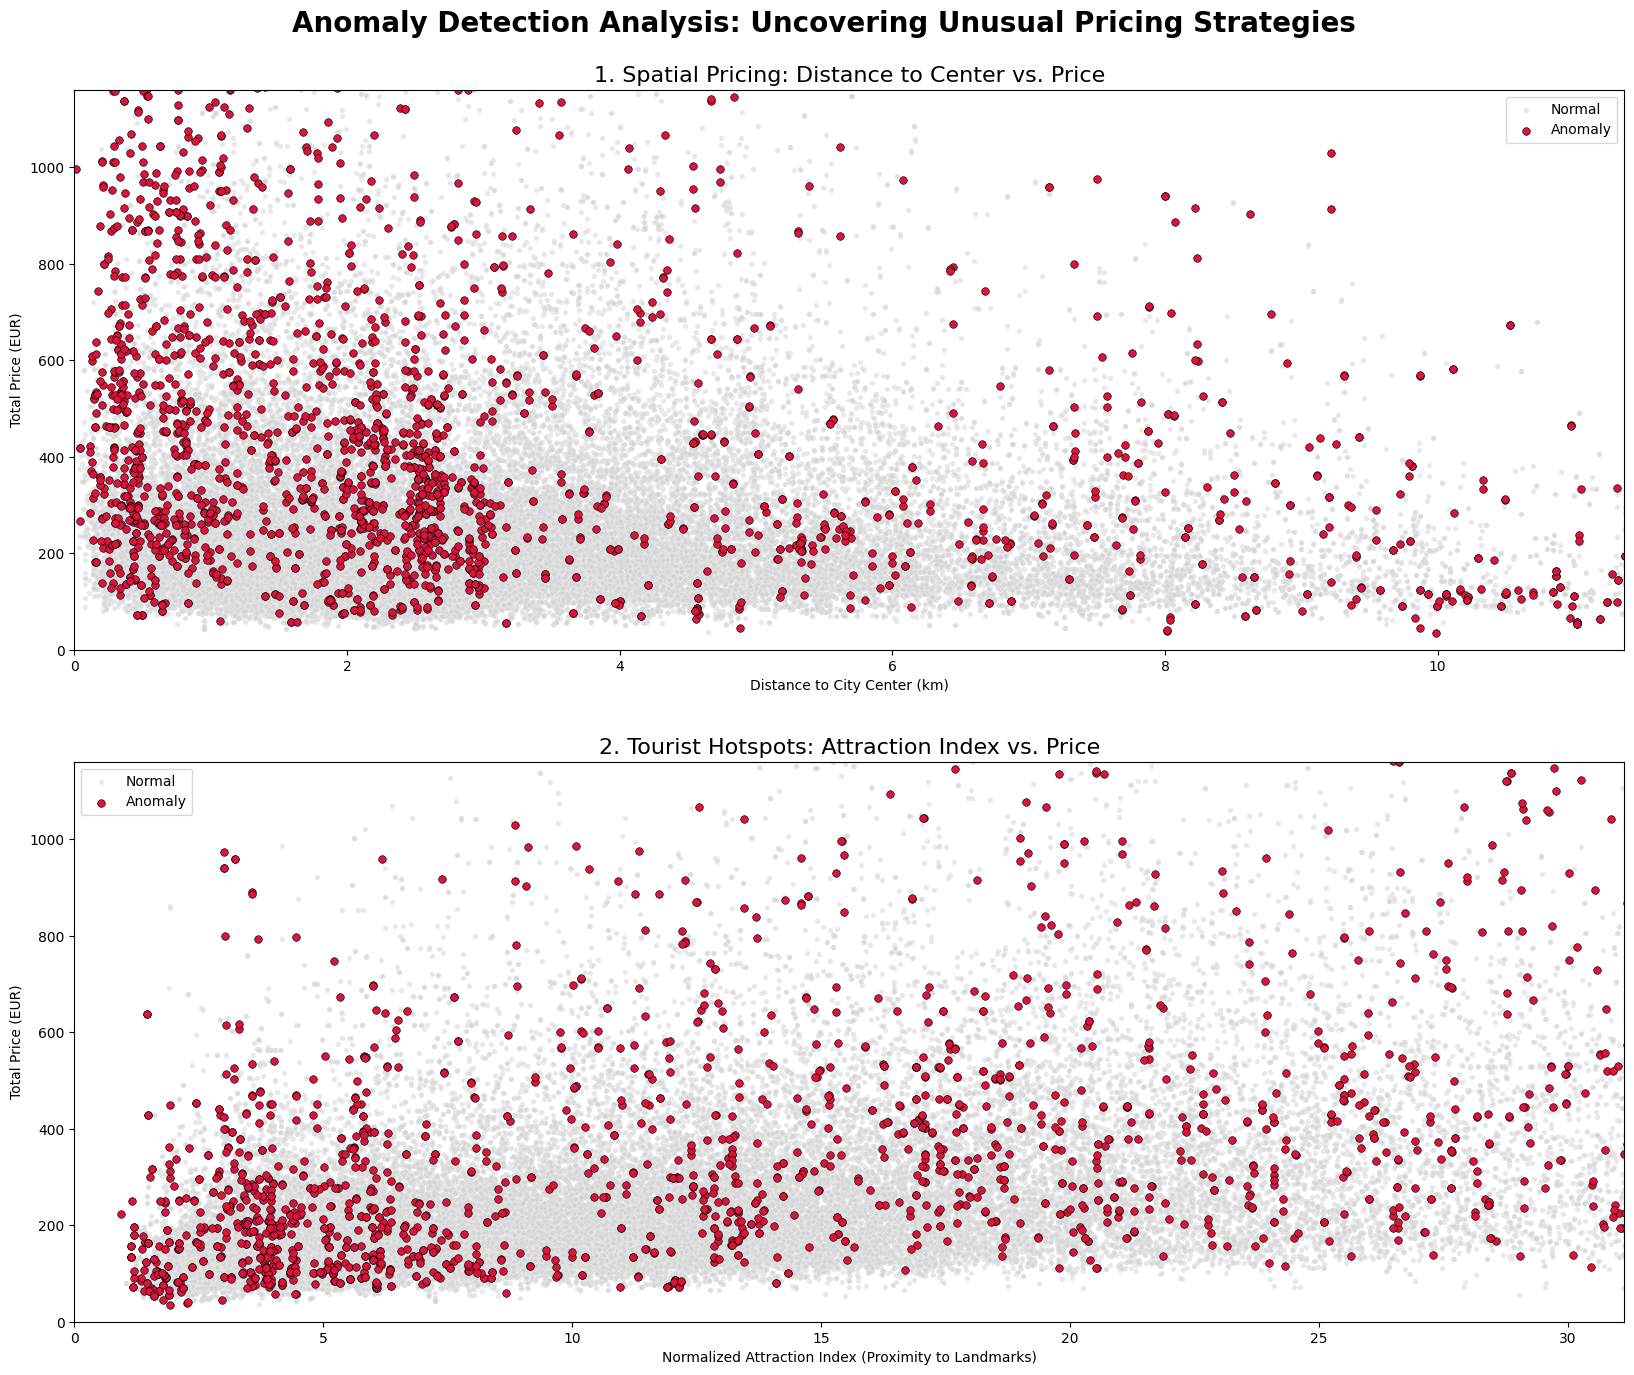

In [33]:
from sklearn.ensemble import IsolationForest

# 1. Prepare Features for Anomaly Detection
# Using spatial features, price, and property quality metrics
# anomaly_features = ['lat', 'lng', 'dist', 'realSum', 'cleanliness_rating', 'guest_satisfaction_overall']
# X_anomaly = df[anomaly_features].dropna()
X_anomaly = df.select_dtypes(include=[np.number]).dropna()
# Scale features to ensure distance metrics and prices are weighted equally
X_anomaly_scaled = StandardScaler().fit_transform(X_anomaly)

# 2. Train Isolation Forest
# n_estimators=300 provides a highly stable, robust ensemble.
# contamination=0.05 assumes the top 5% most unusual listings are anomalies.
iso_forest = IsolationForest(n_estimators=300, contamination=0.05, random_state=42, n_jobs=-1)

# Predict anomalies (-1 = anomaly, 1 = normal)
X_anomaly['anomaly_label'] = iso_forest.fit_predict(X_anomaly_scaled)

# Extract raw continuous anomaly scores (lower score = more anomalous)
X_anomaly['anomaly_score'] = iso_forest.decision_function(X_anomaly_scaled)

#  Feature Engineering for better anomaly context
X_anomaly['price_per_person'] = X_anomaly['realSum'] / X_anomaly['person_capacity']

# Re-split the datasets so the new feature is included in both
anomalies = X_anomaly[X_anomaly['anomaly_label'] == -1]
normal = X_anomaly[X_anomaly['anomaly_label'] == 1]

# Set up a 2x2 grid for the visualizations
fig, axes = plt.subplots(2, 1, figsize=(20, 16))
fig.suptitle("Anomaly Detection Analysis: Uncovering Unusual Pricing Strategies", fontsize=20, fontweight='bold', y=0.93)

# ==========================================
# PLOT 1: Distance vs. Price 
# ==========================================
sns.scatterplot(data=normal, x='dist', y='realSum', color='lightgrey', label='Normal', s=15, alpha=0.5, ax=axes[0])
sns.scatterplot(data=anomalies, x='dist', y='realSum', color='crimson', label='Anomaly', s=30, edgecolor='black', ax=axes[0])
axes[0].set_title("1. Spatial Pricing: Distance to Center vs. Price", fontsize=16)
axes[0].set_xlabel("Distance to City Center (km)")
axes[0].set_ylabel("Total Price (EUR)")
axes[0].set_ylim(0, X_anomaly['realSum'].quantile(0.99))
axes[0].set_xlim(0, X_anomaly['dist'].quantile(0.99))
axes[0].legend()

# ==========================================
# PLOT 2: Attraction Index vs. Price 
# ==========================================
sns.scatterplot(data=normal, x='attr_index_norm', y='realSum', color='lightgrey', label='Normal', s=15, alpha=0.5, ax=axes[1])
sns.scatterplot(data=anomalies, x='attr_index_norm', y='realSum', color='crimson', label='Anomaly', s=30, edgecolor='black', ax=axes[1])
axes[1].set_title("2. Tourist Hotspots: Attraction Index vs. Price", fontsize=16)
axes[1].set_xlabel("Normalized Attraction Index (Proximity to Landmarks)")
axes[1].set_ylabel("Total Price (EUR)")
axes[1].set_ylim(0, X_anomaly['realSum'].quantile(0.99))
# Zooming in on the X-axis to prevent the data from squishing to the left
axes[1].set_xlim(0, X_anomaly['attr_index_norm'].quantile(0.95))
axes[1].legend()


plt.show()

## 5. Predictive Modeling: Do Spatial Features Matter?
Finally, I tested whether geographic information actually improves my ability to predict price (`realSum`). I compared a baseline Random Forest model (using only basic property features) against a spatial model (which includes exact coordinates, distance to the center, and attraction proximity).

## 5. Predictive Modeling: The Incremental Value of Spatial Data

In the previous sections, I discovered clear spatial pricing tiers and detected anomalous pricing strategies. The final step is to test this quantitatively by asking: **Does geographic information actually improve my ability to predict Airbnb prices, and what specific *type* of spatial data matters most?**

To avoid confusing the model with global coordinates (where Paris coordinates mean nothing in Rome), I trained **city-specific models**. For each city, I evaluated three Machine Learning models to measure the incremental value of spatial features:

1. **Baseline Model:** Predicts price using only physical property characteristics, host strategies, and temporal dynamics (e.g., capacity, room type, superhost status, weekend flag).
2. **Geo Model:** Adds pure geographic layout metrics (exact `lat`/`lng` coordinates, distance to the center, and distance to the nearest metro).
3. **Attraction Model (Full Spatial):** Adds the economic context (normalized tourist attraction index and restaurant density index) on top of the Geo model.

Training Baseline, Geo, and Attraction models city-by-city. Please wait...

✅ Modeling Complete! Here is the performance breakdown by city:


,City,Baseline R2,Geo R2,Attraction R2,MAE Base,MAE Geo,MAE Attr
2,Barcelona,0.185,0.888,0.846,95.297,58.205,60.265
0,Amsterdam,0.620,0.782,0.732,162.911,104.643,112.774
5,Lisbon,0.503,0.718,0.698,49.705,33.937,35.793
3,Berlin,0.446,0.702,0.673,72.345,47.599,49.302
8,Rome,0.271,0.682,0.673,55.004,31.145,31.076
7,Paris,0.500,0.712,0.669,107.402,69.466,73.875
1,Athens,0.312,0.714,0.666,42.770,24.814,26.741
6,London,0.200,0.434,0.437,127.349,80.001,78.870
4,Budapest,0.027,0.235,0.165,52.658,40.227,41.023
9,Vienna,0.013,0.034,0.035,76.336,54.830,55.371


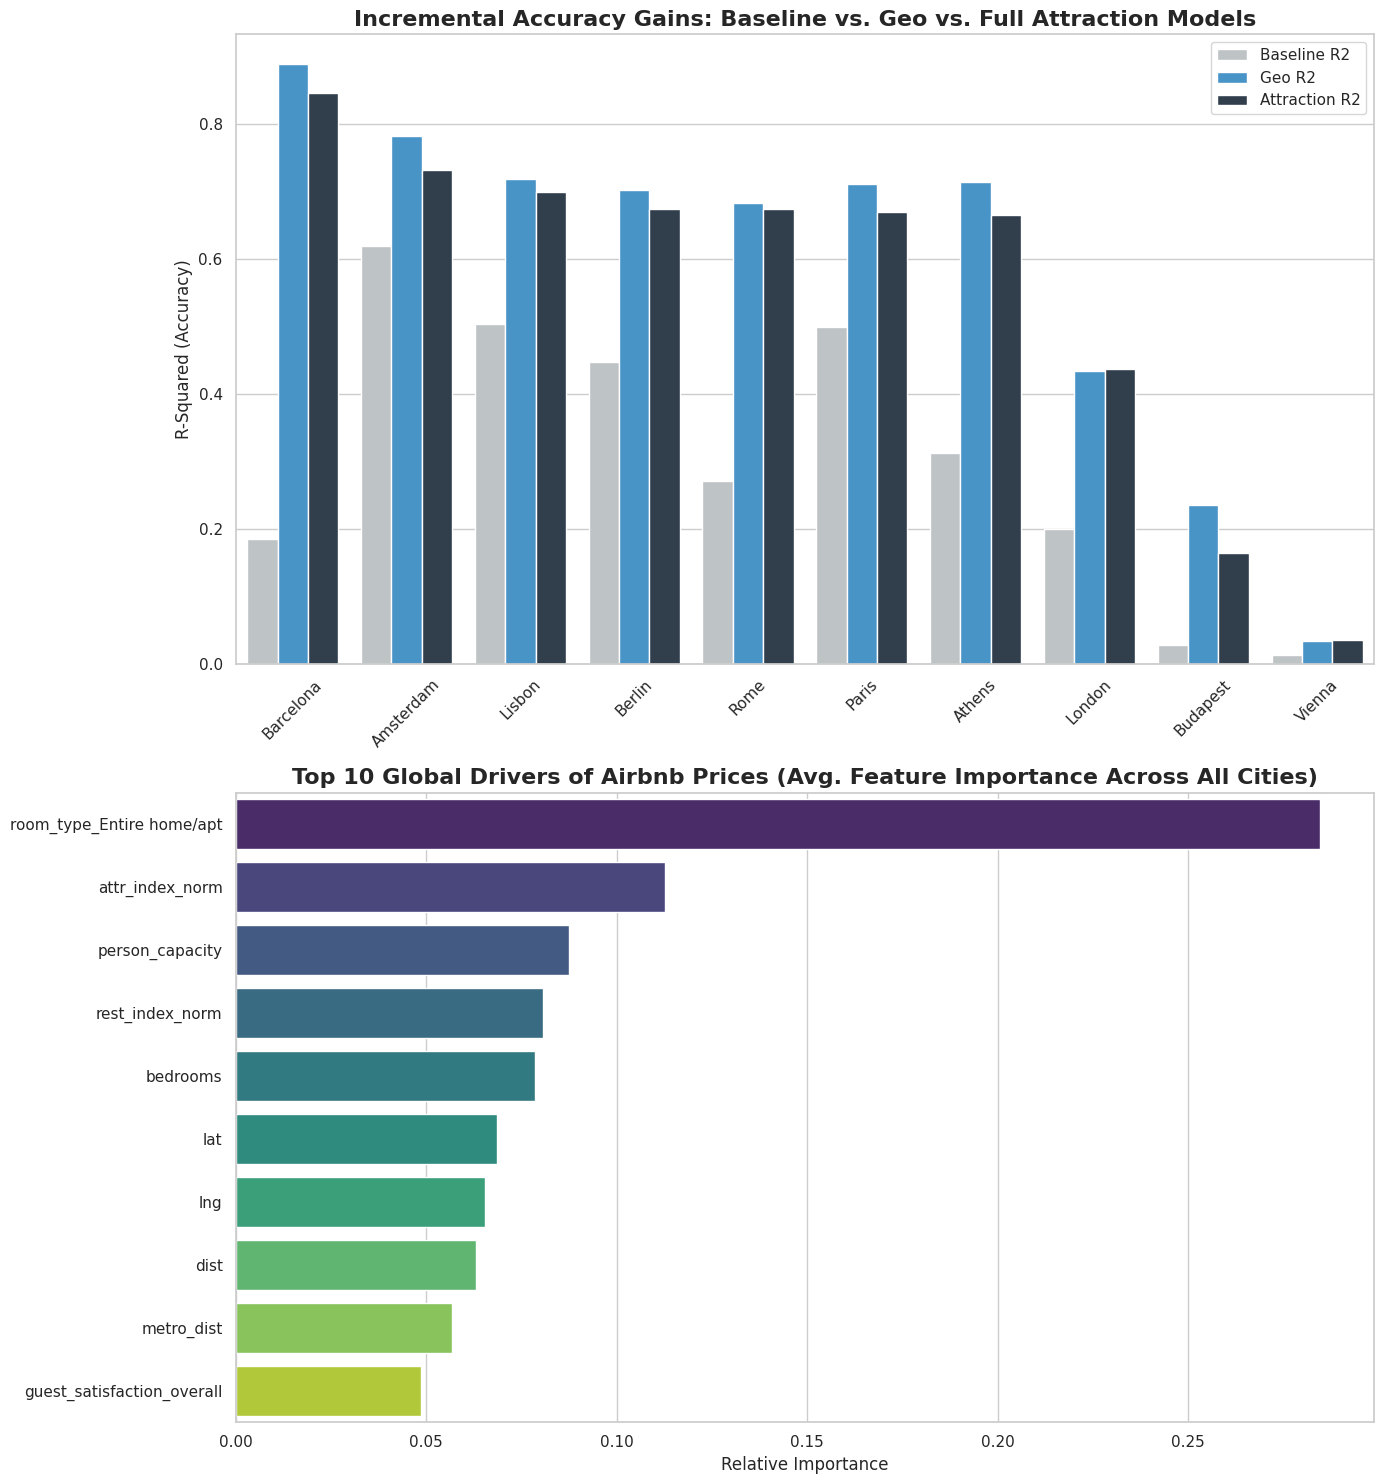

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define Feature Sets incrementally
# Model 1: Physical, Host, and Temporal features
baseline_num = [
    'person_capacity', 'cleanliness_rating', 'guest_satisfaction_overall', 
    'bedrooms', 'host_is_superhost', 'multi', 'biz', 'is_weekend'
]
cat_cols = ['room_type']

# Model 2: Baseline + pure geography and distance
geo_num = baseline_num + ['lat', 'lng', 'dist', 'metro_dist']

# Model 3: Geo + economic/attraction context
attr_num = geo_num + ['attr_index_norm', 'rest_index_norm']

# Prepare master data
all_features = list(set(attr_num + cat_cols))
model_df = df[all_features + ['realSum', 'city']].dropna()

cities = model_df['city'].unique()
results = []
feature_importances_list = []

print("Training Baseline, Geo, and Attraction models city-by-city. Please wait...\n")

# 2. Iterate through each city
for city in cities:
    city_df = model_df[model_df['city'] == city]
    
    if len(city_df) < 100:
        continue
        
    X_base = city_df[baseline_num + cat_cols]
    X_geo  = city_df[geo_num + cat_cols]
    X_attr = city_df[attr_num + cat_cols]
    y = city_df['realSum']
    
    # Identical splits to ensure a fair comparison across all 3 models
    train_idx, test_idx = train_test_split(np.arange(len(city_df)), test_size=0.2, random_state=42)
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # 3. Build Preprocessors
    prep_base = ColumnTransformer([('num', StandardScaler(), baseline_num), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
    prep_geo  = ColumnTransformer([('num', StandardScaler(), geo_num), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
    prep_attr = ColumnTransformer([('num', StandardScaler(), attr_num), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

    # Helper function to generate pipelines
    def build_rf(preprocessor):
        return Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', TransformedTargetRegressor(
                regressor=RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
                func=np.log1p, inverse_func=np.expm1
            ))
        ])

    rf_base = build_rf(prep_base)
    rf_geo  = build_rf(prep_geo)
    rf_attr = build_rf(prep_attr)
    
    # 4. Train & Predict
    rf_base.fit(X_base.iloc[train_idx], y_train)
    y_pred_base = rf_base.predict(X_base.iloc[test_idx])
    
    rf_geo.fit(X_geo.iloc[train_idx], y_train)
    y_pred_geo = rf_geo.predict(X_geo.iloc[test_idx])

    rf_attr.fit(X_attr.iloc[train_idx], y_train)
    y_pred_attr = rf_attr.predict(X_attr.iloc[test_idx])
    
    # 5. Record Metrics
    r2_base = r2_score(y_test, y_pred_base)
    r2_geo  = r2_score(y_test, y_pred_geo)
    r2_attr = r2_score(y_test, y_pred_attr)
    
    results.append({
        'City': city,
        'Baseline R2': r2_base,
        'Geo R2': r2_geo,
        'Attraction R2': r2_attr,
        'MAE Base': mean_absolute_error(y_test, y_pred_base),
        'MAE Geo': mean_absolute_error(y_test, y_pred_geo),
        'MAE Attr': mean_absolute_error(y_test, y_pred_attr)
    })
    
    # 6. Record Feature Importances from the most complex model (Attr)
    ohe_names = rf_attr.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_cols)
    all_names = attr_num + list(ohe_names)
    importances = rf_attr.named_steps['regressor'].regressor_.feature_importances_
    
    for name, imp in zip(all_names, importances):
        feature_importances_list.append({'City': city, 'Feature': name, 'Importance': imp})

# ==========================================
# 7. Compile and Display Results
# ==========================================
results_df = pd.DataFrame(results).sort_values(by='Attraction R2', ascending=False)
print("✅ Modeling Complete! Here is the performance breakdown by city:")
display(results_df.round(3))

# ==========================================
# 8. Visualizations
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 15))

# Plot A: Model Comparison by City (Now with 3 bars!)
results_melted = results_df.melt(
    id_vars='City', 
    value_vars=['Baseline R2', 'Geo R2', 'Attraction R2'], 
    var_name='Model Set', 
    value_name='R2 Score'
)

sns.barplot(data=results_melted, x='City', y='R2 Score', hue='Model Set', palette=['#bdc3c7', '#3498db', '#2c3e50'], ax=axes[0])
axes[0].set_title("Incremental Accuracy Gains: Baseline vs. Geo vs. Full Attraction Models", fontsize=16, fontweight='bold')
axes[0].set_ylabel("R-Squared (Accuracy)")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="")

# Plot B: Aggregate Feature Importance
fi_df = pd.DataFrame(feature_importances_list)
avg_fi = fi_df.groupby('Feature')['Importance'].mean().reset_index().sort_values(by='Importance', ascending=False).head(10)

sns.barplot(data=avg_fi, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title("Top 10 Global Drivers of Airbnb Prices (Avg. Feature Importance Across All Cities)", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Relative Importance")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# 🏁 Project Conclusion: Decoding the European Airbnb Market

Through this multi-stage data science workflow, we have successfully moved beyond basic property descriptions to understand the complex economic and geographic forces driving Airbnb prices across ten major European cities.

---

### 1. Market Segmentation (Clustering)
By applying **K-Means** and **DBSCAN** clustering, we transitioned from 50,000 individual data points to a structured view of the market:
* **Economic Tiers**: We identified distinct price clusters (Budget, Mid-Range, and Luxury) that show a consistent pricing structure across different European markets.
* **Geographic Hubs**: DBSCAN successfully mapped high-density accommodation hubs, identifying the "beating heart" of each city where tourism and transit converge.

---

### 2. Identifying Pricing Outliers (Anomaly Detection)
Using **Isolation Forest**, we identified listings that violated standard market logic:
* **Spatial Mismatches**: We flagged listings that command premium prices despite being far from the city center or located in areas with a low Attraction Index.
* **Service Gaps**: Anomalies were frequently found in properties where high price tags did not align with cleanliness or overall guest satisfaction scores.
* **Strategic Insights**: These outliers often represent either unique "niche" properties or aggressive, opportunistic pricing strategies by hosts that do not follow general market trends.

---

### 3. The Incremental Value of Spatial Data (Modeling)
Our predictive modeling proved that **where** an apartment is matters as much as—or more than—**what** the apartment is:
* **Massive Accuracy Gains**: Moving from a **Baseline Model** to a **Geo Model** (adding `lat`, `lng`, and `dist`) resulted in dramatic $R^2$ improvements, particularly in markets like Barcelona, Amsterdam, and Athens.
* **Contextual Refinement**: Adding the **Attraction Index** (economic context) provided an additional layer of precision, helping to differentiate prices in high-density tourist zones.
* **Feature Dominance**: While `room_type_Entire home/apt` remains the strongest single predictor, geographic features like `attr_index_norm`, `lat`, `lng`, and `dist` dominate the top 10 most important drivers of price.
* **Error Reduction**: In cities like Athens, the Mean Absolute Error (MAE) was reduced from approximately **€42.77** to **€26.74**, nearly cutting the prediction error in half through spatial data alone.

---

### 💡 Final Takeaway
This analysis demonstrates that Airbnb pricing is a fundamentally spatial phenomenon. While physical features like bedrooms and capacity provide the baseline for a property's value, the local geographic context—proximity to metro lines, restaurant density, and tourist attractions—determines the premium a host can realistically charge. For investors and travelers alike, these models offer a data-backed lens to identify fair market value in a complex international landscape.